# Humor Classifier

## Main idea
The idea of the classifier is to see if a machine learning algorithm is able to predict humor within a text with using several aspects of language, specifically theories of humour:
<ul>
<li> Incongruity theory – humour emerges from anything that is contrary to what we expect
<li> Hostility theory and superiority theory – humour used to make fun of other people, certain groups
<li> Relief theory – dark humour used to reduce stress after harmful events
</ul>

## Overview



Features:

Associated with incongruity:
*   Surprise rate (bigram)
*   Surprise rate (trigram)
*   Surprise rate (4gram)
*   Surprise rate (PPMI) for collocations adj+noun
*   Word2vec similarity

Associated with relief theory (dark humour):
*   Sentiment analysis (binary)

Associated with hostility theory:
*   Named entities occurence

Additionally:
*   Occurence of words considered 'funny'



## Text extractions
### Humourous texts
The 'funny' texts used to train the model come from the book $\textbf{1001 jokes}$ by Richard Wiseman

First let us use `requests` library to download the source file

In [ ]:
import requests as req
url = "https://richardwiseman.wordpress.com/wp-content/uploads/2011/09/jokes1.pdf"
r = req.get(url)
if r.status_code == 200:
  with open("jokes.pdf", "wb") as f:
    f.write(r.content)

And now we can proceed with `pdfplumber` to extract the text from the file:

In [ ]:
!pip install pdfplumber

In [ ]:
import pdfplumber
import re

def extract_text(pdf_path: str) -> str:
    all_text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            txt = page.extract_text() or ""
            all_text.append(txt)
    raw = "\n".join(all_text)
    cleaned = re.sub(r"\s+", " ", raw).strip()
    return cleaned

jokes_raw = extract_text("jokes.pdf")


This function also helps with a preliminary preprocessing as it removes whitespace from the text

In [ ]:
print(jokes_raw)

1001 Jokes A few years ago Richard Wiseman went in search of the world's funniest joke. The results are described in his book, Quirkology. Here are the first 1001 clean jokes submitted into the database. Enjoy..... 37 Is it true that cannibals don't eat clowns because they taste funny? 38 What kind of pig can you ignore at a party? A wild bore. 39 What kind of murderer has fiber? A cereal killer. 44 A man walking down the streets sees another man with a very big dog. One man says to the other, "Does your dog bite", the man replies "No my dog doesn't" The man pats the dog and has his hand bitten off, "I thought you said your dog didn't bite" said the injured man. "Thats not my dog", replied the other. 45 Q: What's the difference between a shoping trolley and a University vice chancellor? A: You fill them both up with as much food and alcohol you can, but it's only the shopping trolley that has a mind of its own. 46 Q. How do you catch a polar bear? A. You cut a hole in the ice and you p

The next stage is to extract each joke as a single string and add it to the list

In [ ]:
import re

def extract_jokes(text):
  parts = re.split(r'\s*\d+\s*', text)
  return [p.strip() for p in parts if p.strip()]

jokes = extract_jokes(jokes_raw)
del(jokes[0])

Now we can obtain regular, not-humourous texts:

In [ ]:
import nltk
nltk.download('brown')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.corpus import brown
from nltk.tokenize.treebank import TreebankWordDetokenizer

sentences = list(brown.sents(categories='fiction'))
detokenizer = TreebankWordDetokenizer()

In order to make 'chunks' of texts of comparable size to jokes let us make a list of merged sentences:

In [ ]:
texts = []
for i in range(0, len(sentences), 2):
    tokens = sentences[i].copy()
    if i + 1 < len(sentences):
        tokens += sentences[i+1]
    texts.append(detokenizer.detokenize(tokens))

Now we can use these lists of texts and transform them into dataframes so that to each text the previously established features could be added

In [ ]:
import pandas as pd
texts_df = pd.DataFrame(texts, columns=['text'])
jokes_df = pd.DataFrame(jokes, columns=['text'])

## Incongruity features
For each text in the dataframe one of the features will be calculated

### Surprise rate
First we can build the n-gram models that will be trained on tokens from Brown.
We can start by establishing a large corpus of tokens

In [ ]:
nltk.download('gutenberg')
nltk.download('reuters')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package reuters to /root/nltk_data...
[nltk_data]   Package reuters is already up-to-date!


True

In [ ]:
import math
from nltk import ngrams, FreqDist, ConditionalFreqDist, ConditionalProbDist, MLEProbDist, word_tokenize, pos_tag
from nltk.corpus import brown, gutenberg, reuters
from nltk.tokenize.treebank import TreebankWordDetokenizer

tokens = (
    [w.lower() for w in brown.words()] +
    [w.lower() for w in gutenberg.words()] +
    [w.lower() for w in reuters.words()]
)

In [ ]:
def build_ngram_models(corpus_tokens, max_n=4):
    ngram_models = {}
    for n in range(2, max_n + 1):
      cfd = ConditionalFreqDist()
      for ngram in ngrams(corpus_tokens, n, pad_left=True, pad_right=True, left_pad_symbol='<s>', right_pad_symbol='</s>'):
          context, word = ngram[:-1], ngram[-1]
          cfd[context][word] +=1
      ngram_models[n] = ConditionalProbDist(cfd, MLEProbDist)
    return ngram_models
ngram_models = build_ngram_models(tokens, 4)

Function to calculate surprise rate where n is a size of an ngram using:
$$surprise\_rate = \Sigma-log_2P$$

In [ ]:
def surprise_rate(text, n, ngram_models):
  tokens = word_tokenize(text.lower())
  model = ngram_models.get(n)
  if model is None:
    return None
  log_prob_sum = 0
  num_ngrams = 0
  for ngram in ngrams(tokens, n, pad_left=True, pad_right=True, left_pad_symbol='<s>', right_pad_symbol='</s>'):
    context, word = ngram[:-1], ngram[-1]
    log_prob = math.log2(model[context].prob(word) if model[context].prob(word) > 0 else 1e-10)
    log_prob_sum += -log_prob
    num_ngrams += 1
  return log_prob_sum / num_ngrams if num_ngrams > 0 else 0

Statistics for ppmi:

In [ ]:
unigram_fd = FreqDist(tokens)
bigram_fd = FreqDist(ngrams(tokens, 2, pad_left=True, pad_right=True, left_pad_symbol='<s>', right_pad_symbol='</s>'))
TOTAL_TOKENS = len(tokens)
TOTAL_BIGRAMS = len(bigram_fd)

We define ppmi as:
$$PPMI(w_1, w_2) = max\left(log_2\frac{P(w_1, w_2)}{P(w_1)P(w_2)}\right)$$

In [ ]:
def ppmi(w1, w2):
  p12 = bigram_fd[(w1, w2)] / TOTAL_TOKENS
  if p12 == 0:
    return 0
  p1 = unigram_fd[w1] / TOTAL_TOKENS
  p2 = unigram_fd[w2] / TOTAL_TOKENS
  return max(math.log2(p12 / (p1 * p2)), 0)

Now we can construct a function that will calculate the feature: ppmi for each pair adjective + noun

In [ ]:
def ppmi_adj_noun(text):
  tokens = word_tokenize(text.lower())
  tagged = pos_tag(tokens)
  adj_noun_pairs = []
  for (w1, t1), (w2, t2) in zip(tagged, tagged[1:]):
    if t1.startswith('JJ') and t2.startswith('NN'):
      adj_noun_pairs.append(ppmi(w1.lower(), w2.lower()))
  return sum(adj_noun_pairs)/len(adj_noun_pairs) if adj_noun_pairs else 0

Now we can apply these functions to dataframes:

In [ ]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
max_ngram = 4
for n in range(2, max_ngram+1):
    texts_df[f"surprise_{n}"] = texts_df['text'].apply(lambda t: surprise_rate(t, n, ngram_models))
    jokes_df[f"surprise_{n}"] = jokes_df['text'].apply(lambda t: surprise_rate(t, n, ngram_models))

texts_df['ppmi_adj_noun'] = texts_df['text'].apply(ppmi_adj_noun)
jokes_df['ppmi_adj_noun'] = jokes_df['text'].apply(ppmi_adj_noun)


### Word2vec similarity
Incongruity can also be measured of how coherent the text is based on word2vec similarity

In [ ]:
!pip install gensim

In [ ]:
import numpy
import gensim.downloader as api
from gensim.models import KeyedVectors

word2vec_model = api.load("word2vec-google-news-300")

def word2vec_similarity(text):
  tokens = [w.lower() for w in word_tokenize(text)]
  if len(tokens) < 2:
    return 0
  similarities = []
  for i in range(len(tokens)-1):
    w1, w2 = tokens[i], tokens[i+1]
    if w1 in word2vec_model and w2 in word2vec_model:
      similarities.append(word2vec_model.similarity(w1, w2))
  return sum(similarities)/len(similarities) if similarities else 0

In [ ]:
texts_df['word2vec_similarity'] = texts_df['text'].apply(word2vec_similarity)
jokes_df['word2vec_similarity'] = jokes_df['text'].apply(word2vec_similarity)

## Sentiment analysis
We can test it if humour is more likely to be associated with either negative (dark humour) or positive connotations instead of neutral ones. We can do that using 'VADER' from NLTK

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def sentiment(text):
  return sia.polarity_scores(text)['compound']

texts_df['sentiment'] = texts_df['text'].apply(sentiment)
jokes_df['sentiment'] = jokes_df['text'].apply(sentiment)

## Named entity recognition
Next we can find out if we tend to make fun of celebrities, countries etc in jokes. Specifically we can construct a feature that evaluates occureence of named entities in the text.

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

def named_entities(text):
  doc = nlp(text)
  return len(doc.ents)

texts_df['named_entities'] = texts_df['text'].apply(named_entities)
jokes_df['named_entities'] = jokes_df['text'].apply(named_entities)

### Words associated with humour

Let us see if a qa transformer can enlist words associated with humour

In [ ]:
from transformers import pipeline

qa = pipeline("question-answering", model ="distilbert-base-uncased-distilled-squad",
              tokenizer="distilbert-base-uncased-distilled-squad", handle_impossible_answer=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cpu


In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()
def extract_funny_words(text, topk=5, score_thresh=0.3):
  out = qa(question="List up to five individual words that are used in a humorous or funny way in the following text. Return an empty answer if there are none.",
           context = text, topk = topk)
  candidates = out if isinstance(out, list) else [out]
  words = []
  for c in candidates:
    ans = c.get('answer', "").strip()
    score = c.get('score', 0)
    if not ans:
      continue
    if c['score'] < score_thresh:
      continue
    tokens = word_tokenize(ans)
    if len(tokens) == 1 and tokens[0].isalpha():
      words.append(tokens[0].lower())
  return list(dict.fromkeys(words))

texts_merged = pd.concat([
    texts_df['text'].rename('text'),
    jokes_df['text'].rename('text')
], ignore_index=True)

funny_words_series = texts_merged.progress_apply(extract_funny_words)
funny_vocabulary = set(w.lower() for words in funny_words_series for w in words)

  0%|          | 0/3207 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/transformers/pipelines/question_answering.py:334: UserWarning: topk parameter is deprecated, use top_k instead
  warnings.warn("topk parameter is deprecated, use top_k instead", UserWarning)


In [ ]:
def count_funny_words(text):
  tokens = word_tokenize(text.lower())
  return len([w for w in tokens if w in funny_vocabulary])

texts_df['funny_words'] = texts_df['text'].apply(count_funny_words)
jokes_df['funny_words'] = jokes_df['text'].apply(count_funny_words)

## Exploratory data analysis

Let us take a look at descriptive statistics

In [ ]:
texts_df.describe()

,surprise_2,surprise_3,surprise_4,ppmi_adj_noun,word2vec_similarity,sentiment,named_entities,funny_words
count,2125.000000,2125.000000,2125.000000,2125.000000,2125.000000,2125.000000,2125.000000,2125.000000
mean,9.702870,9.280758,9.685126,5.094662,0.185043,0.014552,1.344000,0.316706
std,1.929292,3.521177,4.932097,4.923691,0.052875,0.454637,1.493163,0.626568
min,6.571066,3.911023,2.134275,0.000000,0.000000,-0.959500,0.000000,0.000000
25%,8.374537,6.787413,6.079661,0.000000,0.152078,-0.312500,0.000000,0.000000
50%,9.209972,8.351064,8.504243,5.154287,0.181296,0.000000,1.000000,0.000000
75%,10.453129,10.905383,12.130030,8.800698,0.213863,0.361200,2.000000,0.000000
max,21.344960,30.663952,33.219281,22.391972,0.547574,0.968300,13.000000,4.000000


In [ ]:
jokes_df.describe()

,surprise_2,surprise_3,surprise_4,ppmi_adj_noun,word2vec_similarity,sentiment,named_entities,funny_words
count,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000,1082.000000
mean,17.653093,26.610874,31.695580,0.966424,0.182517,-0.000025,1.215342,1.044362
std,5.094299,3.988239,1.776164,2.085835,0.072453,0.418200,2.020438,1.553210
min,8.871107,14.292178,19.455972,0.000000,-0.018072,-0.992400,0.000000,0.000000
25%,14.000130,23.544027,30.626429,0.000000,0.152435,-0.177325,0.000000,0.000000
50%,16.552039,26.764705,32.077162,0.000000,0.183615,0.000000,0.500000,1.000000
75%,19.654396,29.492060,33.219281,0.000000,0.222866,0.189625,2.000000,1.000000
max,33.219281,33.219281,33.219281,15.677726,0.462000,0.984800,19.000000,11.000000


We can marge the dataframes:

In [ ]:
texts_df['humour'] = 0
jokes_df['humour'] = 1

df = pd.concat([texts_df, jokes_df], ignore_index=True).drop('text', axis=1)

And see what features are correlated with humour:

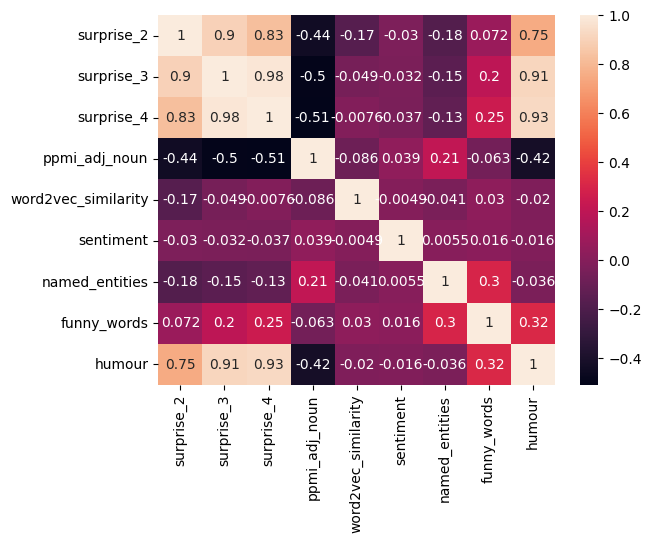

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

As we can see the biggest (absolute value) correlations humour has with features associated with incongruity, no correlation with sentiment, word2vec similarity and named entities occurence and relatively small correlation with the occurence of 'funny words'.

## Humour classifier

Let us test how well can we predict humour from the features we prepared

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

model = LogisticRegression()
model.fit(df_train.drop(['humour'], axis=1), df_train['humour'])
predictions = model.predict(df_test.drop(['humour'], axis=1))
print(classification_report(df_test['humour'], predictions))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       420
           1       0.97      1.00      0.99       221

    accuracy                           0.99       641
   macro avg       0.99      0.99      0.99       641
weighted avg       0.99      0.99      0.99       641



As we can see the model has very high evaluation metrics. Let us see how the confusion matrix looks like:

<Axes: >

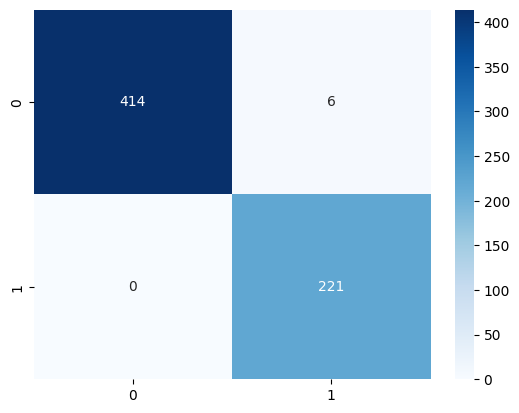

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_test['humour'], predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

We can use tools such as `dalex` to see what features contributes the most to the high accuracy of the model

In [ ]:
!pip install dalex

In [ ]:
import dalex as dx

exp = dx.Explainer(model, df_train.drop(['humour'], axis=1), df_train['humour'])
variable_importance = exp.model_parts(N=1000, B=15, random_state=11)
print(variable_importance)

Preparation of a new explainer is initiated

  -> data              : 2566 rows 8 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2566 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x78138018e8e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 1.89e-08, mean = 0.336, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.998, mean = 2.99e-07, max = 0.994
  -> model_info        : package sklearn

A new explainer has been created!


In [ ]:
variable_importance.plot()

As we can see the entire classifier is based only on the feature `surprise_4`

For exploratory purposes let us analyse what would be the performance of the model without this feature and what would contribute to the model the most then.

In [ ]:
df

,surprise_2,surprise_3,surprise_4,ppmi_adj_noun,word2vec_similarity,sentiment,named_entities,funny_words,humour
0,10.387716,14.119035,17.521372,16.391972,0.379572,0.0000,1,0,0
1,7.462081,4.812094,2.925232,6.356390,0.192546,0.5669,2,0,0
2,7.966592,6.326810,4.941555,15.370458,0.185183,0.4867,2,0,0
3,9.021260,6.812845,6.363713,10.150792,0.148865,0.6249,2,0,0
4,9.287357,5.868693,5.266852,8.773273,0.153166,0.3612,3,0,0
...,...,...,...,...,...,...,...,...,...
3202,13.981810,22.913693,32.544763,0.000000,0.224066,0.1154,2,2,1
3203,15.230004,24.601098,31.194674,1.069271,0.182197,-0.6239,1,1,1
3204,25.838843,31.071329,33.219281,0.000000,0.036951,0.0000,0,1,1
3205,14.686666,22.079454,29.170396,0.000000,0.190028,-0.7845,0,2,1


In [ ]:
df2 = df.drop(["surprise_4"], axis = 1)
df2_train = df2.sample(frac=0.8, random_state=42)
df2_test = df2.drop(df_train.index)

model2 = LogisticRegression()
model2.fit(df2_train.drop(['humour'], axis=1), df2_train['humour'])
predictions = model2.predict(df2_test.drop(['humour'], axis=1))
print(classification_report(df2_test['humour'], predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       420
           1       0.96      0.98      0.97       221

    accuracy                           0.98       641
   macro avg       0.98      0.98      0.98       641
weighted avg       0.98      0.98      0.98       641



The performance is still great!

<Axes: >

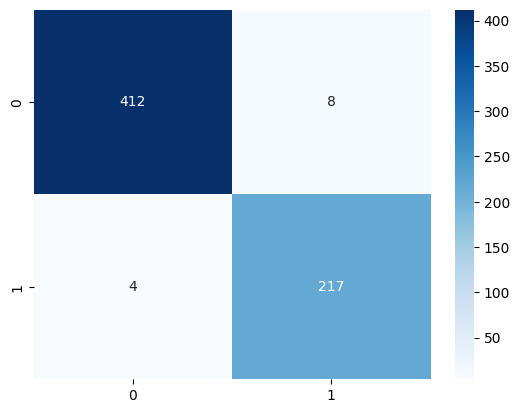

In [ ]:
cm = confusion_matrix(df2_test['humour'], predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

As we can see there are slightly more wrongly assigned texts

In [ ]:
exp = dx.Explainer(model2, df2_train.drop(['humour'], axis=1), df2_train['humour'])
variable_importance = exp.model_parts(N=1000, B=15, random_state=11)
variable_importance.plot()

Preparation of a new explainer is initiated

  -> data              : 2566 rows 7 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2566 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x78138018e8e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 1.19e-06, mean = 0.336, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.0, mean = -2.03e-06, max = 0.979
  -> model_info        : package sklearn

A new explainer has been created!


It is not particularly surprising that this model is very similar to the previous one: there is one dominant feature and this time it is `surprise_3`.

Lastly let us see and evaluate the performance of the model without any surprise rates:

In [ ]:
df3 = df.drop(["surprise_2", "surprise_3", "surprise_4"], axis = 1)
df3_train = df3.sample(frac=0.8, random_state=42)
df3_test = df3.drop(df_train.index)

model3 = LogisticRegression()
model3.fit(df3_train.drop(['humour'], axis=1), df3_train['humour'])
predictions = model3.predict(df3_test.drop(['humour'], axis=1))
print(classification_report(df3_test['humour'], predictions))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       420
           1       0.73      0.46      0.56       221

    accuracy                           0.76       641
   macro avg       0.75      0.68      0.70       641
weighted avg       0.75      0.76      0.74       641



Now the metrics seem to be more balanced

<Axes: >

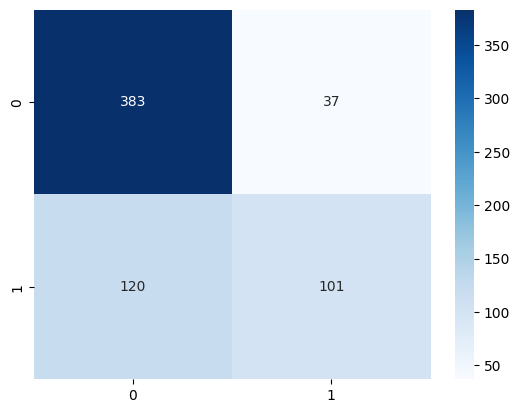

In [ ]:
cm = confusion_matrix(df3_test['humour'], predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

As we can see from the confusion matrix, there are 120 non-humourous texts that were classified as humourous. It is surprising, because this number is lower than true positives (humourous texts classified as such)

In [ ]:
exp = dx.Explainer(model3, df3_train.drop(['humour'], axis=1), df3_train['humour'])
variable_importance = exp.model_parts(N=1000, B=15, random_state=11)
variable_importance.plot()

Preparation of a new explainer is initiated

  -> data              : 2566 rows 5 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2566 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x78138018e8e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.00031, mean = 0.336, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.97, mean = -7.55e-05, max = 0.987
  -> model_info        : package sklearn

A new explainer has been created!


### Another approach

The key limitation of the previous models is that these very efficient features that focus on incongruity were trained on the texts they analysed. Now we can see whether removing 'Brown' from the training tokens will keep high accuracy of the model.

In [ ]:
tokens_no_brown = (
    [w.lower() for w in gutenberg.words()] +
    [w.lower() for w in reuters.words()]
)

In [ ]:
new_ngram_models = build_ngram_models(tokens_no_brown, 4)
new_unigram_fd = FreqDist(tokens_no_brown)
new_bigram_fd = FreqDist(ngrams(tokens_no_brown, 2, pad_left=True, pad_right=True, left_pad_symbol='<s>', right_pad_symbol='</s>'))
TOTAL_TOKENS = len(tokens_no_brown)
TOTAL_BIGRAMS = len(new_bigram_fd)

In [ ]:
def new_ppmi(w1, w2):
  p12 = new_bigram_fd[(w1, w2)] / TOTAL_TOKENS
  if p12 == 0:
    return 0
  p1 = new_unigram_fd[w1] / TOTAL_TOKENS
  p2 = new_unigram_fd[w2] / TOTAL_TOKENS
  return max(math.log2(p12 / (p1 * p2)), 0)

def new_ppmi_adj_noun(text):
  tokens = word_tokenize(text.lower())
  tagged = pos_tag(tokens)
  adj_noun_pairs = []
  for (w1, t1), (w2, t2) in zip(tagged, tagged[1:]):
    if t1.startswith('JJ') and t2.startswith('NN'):
      adj_noun_pairs.append(new_ppmi(w1.lower(), w2.lower()))
  return sum(adj_noun_pairs)/len(adj_noun_pairs) if adj_noun_pairs else 0

In [ ]:
max_ngram = 4
for n in range(2, max_ngram+1):
  texts_df[f"new_surprise_{n}"] = texts_df['text'].apply(lambda t: surprise_rate(t, n, new_ngram_models))
  texts_df.drop(f"surprise_{n}", axis=1, inplace=True)
  jokes_df[f"new_surprise_{n}"] = jokes_df['text'].apply(lambda t: surprise_rate(t, n, new_ngram_models))
  jokes_df.drop(f"surprise_{n}", axis=1, inplace=True)

texts_df['new_ppmi_adj_noun'] = texts_df['text'].apply(new_ppmi_adj_noun)
texts_df.drop('ppmi_adj_noun', axis=1, inplace=True)
jokes_df['new_ppmi_adj_noun'] = jokes_df['text'].apply(new_ppmi_adj_noun)
jokes_df.drop('ppmi_adj_noun', axis=1, inplace=True)


In [ ]:
df_new = pd.concat([texts_df, jokes_df], ignore_index=True).drop('text', axis=1)

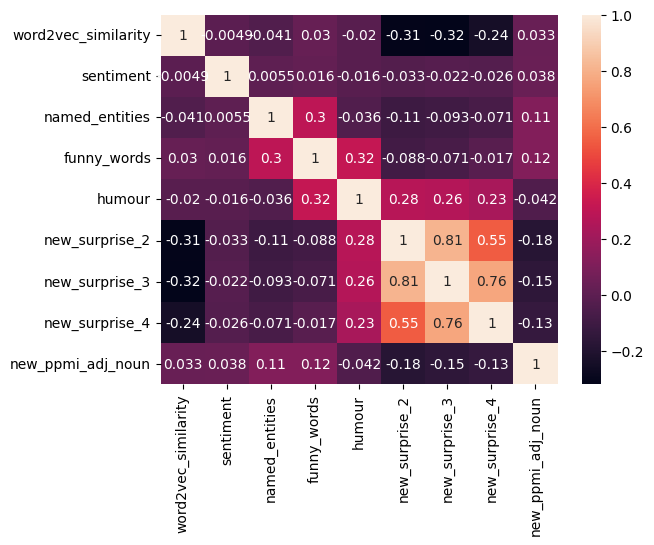

In [ ]:
corr = df_new.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
df_new_train = df_new.sample(frac=0.8, random_state=42)
df_new_test = df_new.drop(df_new_train.index)

model4 = LogisticRegression()
model4.fit(df_new_train.drop(['humour'], axis=1), df_new_train['humour'])
predictions = model4.predict(df_new_test.drop(['humour'], axis=1))
print(classification_report(df_new_test['humour'], predictions))

              precision    recall  f1-score   support

           0       0.75      0.89      0.81       420
           1       0.67      0.44      0.53       221

    accuracy                           0.73       641
   macro avg       0.71      0.66      0.67       641
weighted avg       0.72      0.73      0.71       641



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



<Axes: >

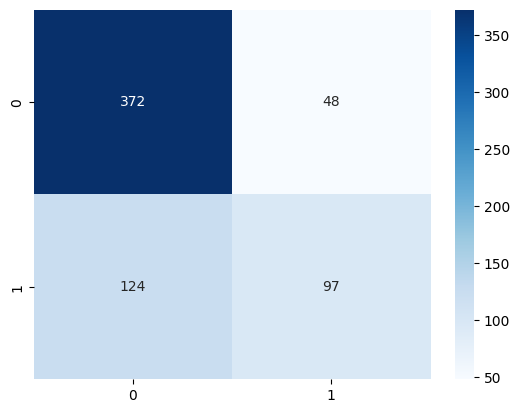

In [ ]:
cm = confusion_matrix(df_new_test['humour'], predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [ ]:
exp = dx.Explainer(model4, df_new_train.drop(['humour'], axis=1), df_new_train['humour'])
variable_importance = exp.model_parts(N=1000, B=15, random_state=11)
variable_importance.plot()

Preparation of a new explainer is initiated

  -> data              : 2566 rows 8 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2566 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x78138018e8e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0151, mean = 0.336, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.953, mean = -0.00056, max = 0.984
  -> model_info        : package sklearn

A new explainer has been created!


Quite surprisingly it turned out that the variable made by the transformer (`funny_words`) is now the most important feature. What is also surprising is that new ppmi feature did not contribute at all to the prediction (new surprise_4 also).

As a one last test let us see the performance of this model but without `funny_words`

In [ ]:
df5 = df_new.drop(["funny_words"], axis = 1)
df5_train = df5.sample(frac=0.8, random_state=42)
df5_test = df5.drop(df5_train.index)

model5 = LogisticRegression()
model5.fit(df5_train.drop(['humour'], axis=1), df5_train['humour'])
predictions = model5.predict(df5_test.drop(['humour'], axis=1))
print(classification_report(df3_test['humour'], predictions))

              precision    recall  f1-score   support

           0       0.68      0.90      0.78       420
           1       0.53      0.21      0.30       221

    accuracy                           0.66       641
   macro avg       0.61      0.56      0.54       641
weighted avg       0.63      0.66      0.61       641



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



<Axes: >

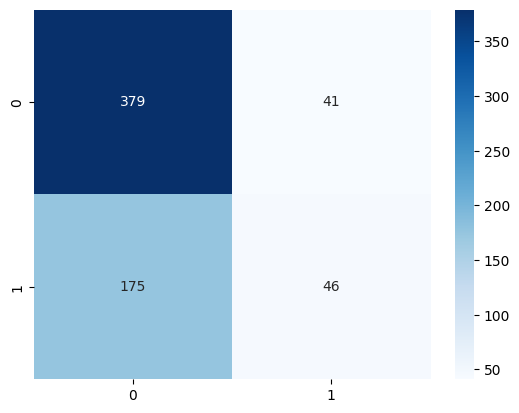

In [ ]:
cm = confusion_matrix(df5_test['humour'], predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [ ]:
exp = dx.Explainer(model5, df5_train.drop(['humour'], axis=1), df5_train['humour'])
variable_importance = exp.model_parts(N=1000, B=15, random_state=11)
variable_importance.plot()

Preparation of a new explainer is initiated

  -> data              : 2566 rows 7 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2566 values
  -> model_class       : sklearn.linear_model._logistic.LogisticRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x78138018e8e0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0289, mean = 0.335, max = 0.813
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.786, mean = 0.000111, max = 0.958
  -> model_info        : package sklearn

A new explainer has been created!


## Discussion

The initial model was extremely efficient (accuracy = 1.0). As it turned out the reason behind that was that the incongruity features (surprise rates and ppmi for adj+noun) were trained on the the non-humourous texts used in the dataframe.

With the new training of the ngrams (excluding Brown texts from the tokens), the accuracy dropped (=0.73), but still reached a relatively high level. Incongruity features, specifically the surprise rate based on the bigrams, were relatively important according to variables importance plot, but the most important predictor was `funny_words` that was made using a transformer. There are however two important limitations of this variable:
<ol>
<li> The list of funny words which occurence was analysed in texts was based on the same texts, hence, it was certain that these words considered as 'funny' would appear in the dataset. A possible extention would be to ask the transformer to look for funny words within the larger corpus or even a corpus without the training/test datasets.
<li> Use of transformer in this classifier did not contribute to linguistic understanding of 'what constitutes a humourous text'. Instead it was rather a test of performance of the transformer in a situation when it is asked to correctly assess if a text is 'funny' or not.
</ol>

Word2vec similarity turned out not to have any predicting power on the data. Similarly, sentiment and named entities were barely used in any of these models.

It is important to highlight, that the accuracy of the last model (without a predictor from the transformer) was still heavily based on 'new' incongruity features (not trained on the training/test data). Nonetheless, the accuracy was only 0.66 and from the confusion matrix we can see that the model very rarely classifies texts as humourous.

The main conclusion is that no matter whether the ngrams were trained on the used data or not, the incongruity features (surprise rates specifically, ppmi for adj+noun on a much smaller scale) constitute the 'humour' of the text which aligns with the notion that humans find texts with unexpected twists 'funny'. The tested models do not confirm hostility and relief theories of humour. It might be that these features exist in situational comedy rather than texts.

Some possible extentions of the project include:
<ul>
<li> Use of additional ML models (Random Forest, XGBoost, MLPClassifier for instance)
<li> Larger corpus of tokens to train ngrams
<li> List of funny words from the transformer gathered from a larger corpus. Comparison between performances of models where the transformer learns the data used in the classifier and when it does not
<li> Larger set of 'humourous' texts including not only 'jokes' but also funny speeches and possible situational comedy. Large corpus of texts with manual annotations could be useful
</ul>